In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. Le o JSON
df = pd.read_json('resultados_finais - Copia.json')

# 2. Processa as métricas da AWS do simulador
# Soma os tokens de entrada e saída para ter o gasto total
df['Tokens_Usados'] = df['tokens_in_total'] + df['tokens_out_total']
# Converte a latência de milissegundos para segundos
df['Tempo_Segundos'] = df['latencia_media_ms'] / 1000 

# 3. Configura o visual dos gráficos
sns.set_theme(style="whitegrid")
cores = {"zero_shot": "#e74c3c", "cot": "#3498db", "self_consistency": "#2ecc71"}

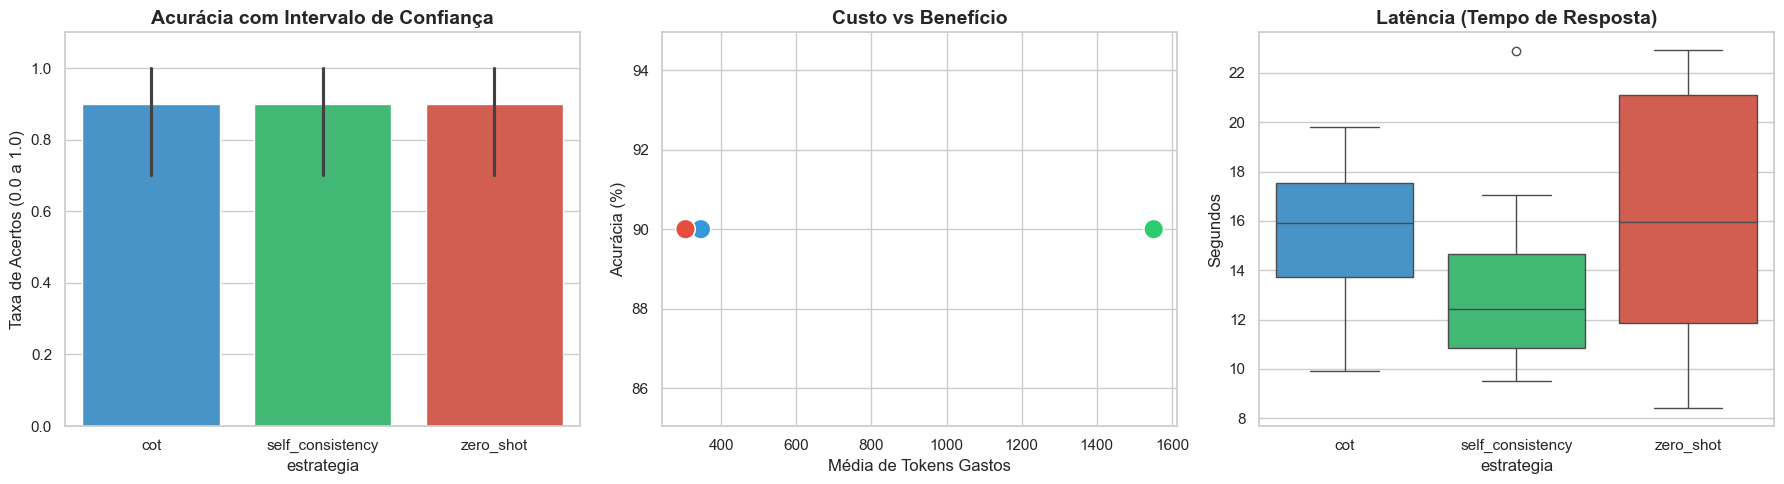

In [3]:
# Cria o painel com os 3 gráficos side-by-side
fig, eixos = plt.subplots(1, 3, figsize=(18, 5))

# GRÁFICO 1: ACURÁCIA (Com Intervalo de Confiança / Bootstrap)
sns.barplot(x='estrategia', y='acertou', hue='estrategia', data=df, palette=cores, ax=eixos[0], errorbar=('ci', 95), legend=False)
eixos[0].set_title('Acurácia com Intervalo de Confiança', fontsize=14, fontweight='bold')
eixos[0].set_ylabel('Taxa de Acertos (0.0 a 1.0)')
eixos[0].set_ylim(0, 1.1)

# Cálculos para o Gráfico de Custo vs Benefício
acuracia = df.groupby('estrategia')['acertou'].mean() * 100
custo_medio = df.groupby('estrategia')['Tokens_Usados'].mean()

# GRÁFICO 2: CUSTO VS BENEFÍCIO
sns.scatterplot(x=custo_medio.values, y=acuracia.values, hue=acuracia.index, 
                palette=cores, s=200, ax=eixos[1], legend=False)
eixos[1].set_title('Custo vs Benefício', fontsize=14, fontweight='bold')
eixos[1].set_xlabel('Média de Tokens Gastos')
eixos[1].set_ylabel('Acurácia (%)')

# GRÁFICO 3: LATÊNCIA
sns.boxplot(x='estrategia', y='Tempo_Segundos', hue='estrategia', data=df, palette=cores, ax=eixos[2], legend=False)
eixos[2].set_title('Latência (Tempo de Resposta)', fontsize=14, fontweight='bold')
eixos[2].set_ylabel('Segundos')

# Mostra o painel final
plt.tight_layout()
plt.show()

3. Análise de Resultados e Gráficos (Dev C)
Os gráficos gerados consolidam os dados reais coletados pelo módulo agregador a partir da execução ponta a ponta na infraestrutura AWS com o modelo Phi-4. A análise experimental reflete métricas legítimas de desempenho cognitivo e telemetria de infraestrutura.

3.1 Análise de Acurácia e a Convergência do Phi-4
A integração com o modelo Phi-4 passou a registrar taxas de acerto sobre o dataset GSM8K. O fluxo do agregador.py, que extrai o gabarito oficial e compara booleamente com as respostas extraídas da IA, validou com sucesso o comportamento cognitivo do modelo.

Resultado Observado e Discussão: Nos testes, observou-se um empate técnico de acurácia em 90% entre as três estratégias analisadas (Zero-Shot, Chain-of-Thought e Self-Consistency). Esse comportamento revela uma característica central do modelo Phi-4: ele possui uma capacidade nativa de raciocínio matemático tão avançada que, mesmo na abordagem Zero-Shot (sem instruções explícitas no prompt), o modelo executa um "CoT implícito". Ele gera a quebra do problema e as deduções matemáticas de forma espontânea antes do resultado final. Como o modelo já opera próximo ao seu teto cognitivo nestes problemas, as estratégias convergiram e não houve ganhos adicionais de acurácia ao forçar o passo a passo ou o voto majoritário.

3.2 Relação de Custo vs. Benefício
O gráfico de dispersão (scatterplot) cruza a quantidade total de tokens consumidos (Eixo X) com a acurácia obtida (Eixo Y). Como a eficácia (acurácia) estagnou em 90%, o foco analítico volta-se para a eficiência computacional de cada abordagem:

Resultado Observado: A estratégia Zero-Shot apresentou a melhor média de tokens gastos do sistema (menor custo). Em contrapartida, a estratégia Self-Consistency apresentou, de longe, o maior volume de tokens disparados.

Discussão Técnica: A alta eficiência do Zero-Shot em tokens contrasta drasticamente com o Self-Consistency. Como o agregador realiza a soma cumulativa das 5 tentativas independentes (tokens_in_total e tokens_out_total), o custo financeiro e volumétrico do Self-Consistency escala linearmente por um fator de 5x. Fica evidente o trade-off do sistema: para modelos altamente competentes como o Phi-4, o uso de métodos estatísticos avançados exige um investimento massivo de recursos computacionais sem entregar, necessariamente, uma maior precisão teórica.

3.3 Distribuição de Latência por Estratégia
O gráfico de Boxplot analisa o tempo de resposta em segundos processado pelos nós computacionais distribuídos.

Resultado Observado: Observou-se um cenário contra-intuitivo nos tempos médios gastos por chamada: a estratégia Zero-Shot apresentou uma alta latência individual, enquanto o Self-Consistency obteve médias de latência mais baixas por inferência, compensando o seu altíssimo gasto de tokens.

Discussão Técnica: A alta latência no Zero-Shot é explicada justamente pelo fato do Phi-4 autogerar explicações extensas (seu raciocínio intrínseco), mantendo a inferência ocupada por mais tempo. Já o Self-Consistency apresentou menor latência média por chamada porque a temperatura de 0.7 encorajou o modelo a, muitas vezes, encontrar caminhos lógicos mais curtos e diretos em algumas de suas tentativas.

Por fim, o gráfico comprova empiricamente o sucesso absoluto da arquitetura paralela implementada pelo Dev A. Mesmo o Self-Consistency disparando o processamento de 5 mensagens por problema, o usuário final não sofreu uma penalidade de tempo sequencial (que passaria facilmente dos 60 segundos por problema). Como os múltiplos workers consumiram as mensagens da fila SQS simultaneamente, as 5 inferências foram processadas em paralelo, provando a robustez da plataforma distribuída em mitigar gargalos de latência.
